In [13]:
# ==========================================
# CREDIT CARD APPROVAL PREDICTION
# Import Required Libraries
# ==========================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Save Model
import pickle

# Display graphs inside notebook
%matplotlib inline

print("All Libraries Imported Successfully")

All Libraries Imported Successfully


In [14]:
# ==========================================
# Read the Datasets
# ==========================================

application_df = pd.read_csv("../dataset/application_record.csv")
credit_df = pd.read_csv("../dataset/credit_record.csv")
print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [15]:
# ==========================================
# Preview Application Dataset
# ==========================================

application_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [16]:
# ==========================================
# Preview Credit Dataset
# ==========================================

credit_df.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [17]:
# ==========================================
# Shape of Application Dataset
# ==========================================

print("Application Dataset Shape")
print(application_df.shape)

Application Dataset Shape
(438557, 18)


In [18]:
# ==========================================
# Application Dataset Information
# ==========================================

application_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  str    
 2   FLAG_OWN_CAR         438557 non-null  str    
 3   FLAG_OWN_REALTY      438557 non-null  str    
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  str    
 7   NAME_EDUCATION_TYPE  438557 non-null  str    
 8   NAME_FAMILY_STATUS   438557 non-null  str    
 9   NAME_HOUSING_TYPE    438557 non-null  str    
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL           438557 

In [19]:
# ==========================================
# Column Names
# ==========================================

print(application_df.columns)

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS'],
      dtype='str')


In [20]:
# ==========================================
# Data Types
# ==========================================

print(application_df.dtypes)

ID                       int64
CODE_GENDER                str
FLAG_OWN_CAR               str
FLAG_OWN_REALTY            str
CNT_CHILDREN             int64
AMT_INCOME_TOTAL       float64
NAME_INCOME_TYPE           str
NAME_EDUCATION_TYPE        str
NAME_FAMILY_STATUS         str
NAME_HOUSING_TYPE          str
DAYS_BIRTH               int64
DAYS_EMPLOYED            int64
FLAG_MOBIL               int64
FLAG_WORK_PHONE          int64
FLAG_PHONE               int64
FLAG_EMAIL               int64
OCCUPATION_TYPE            str
CNT_FAM_MEMBERS        float64
dtype: object


In [21]:
# ==========================================
# Descriptive Statistics
# ==========================================

application_df.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


In [22]:
# ==========================================
# Credit Dataset Shape
# ==========================================

print("Credit Dataset Shape")
print(credit_df.shape)

Credit Dataset Shape
(1048575, 3)


In [23]:
# ==========================================
# Credit Dataset Information
# ==========================================

credit_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype
---  ------          --------------    -----
 0   ID              1048575 non-null  int64
 1   MONTHS_BALANCE  1048575 non-null  int64
 2   STATUS          1048575 non-null  str  
dtypes: int64(2), str(1)
memory usage: 24.0 MB


In [24]:
# ==========================================
# Credit Dataset Column Names
# ==========================================

print(credit_df.columns)

Index(['ID', 'MONTHS_BALANCE', 'STATUS'], dtype='str')


In [25]:
# ==========================================
# Credit Dataset Data Types
# ==========================================

print(credit_df.dtypes)

ID                int64
MONTHS_BALANCE    int64
STATUS              str
dtype: object


In [26]:
# ==========================================
# Credit Dataset Statistics
# ==========================================

credit_df.describe()

,ID,MONTHS_BALANCE
count,1.048575e+06,1.048575e+06
mean,5.068286e+06,-1.913700e+01
std,4.615058e+04,1.402350e+01
min,5.001711e+06,-6.000000e+01
25%,5.023644e+06,-2.900000e+01
50%,5.062104e+06,-1.700000e+01
75%,5.113856e+06,-7.000000e+00
max,5.150487e+06,0.000000e+00


In [27]:
# ==========================================
# Missing Values Count
# ==========================================

print("Missing Values in Application Dataset")
print(application_df.isnull().sum())

Missing Values in Application Dataset
ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64


In [28]:
# ==========================================
# Missing Value Percentage
# ==========================================

missing_percentage = (application_df.isnull().sum() / len(application_df)) *  100
print(missing_percentage)

ID                      0.000000
CODE_GENDER             0.000000
FLAG_OWN_CAR            0.000000
FLAG_OWN_REALTY         0.000000
CNT_CHILDREN            0.000000
AMT_INCOME_TOTAL        0.000000
NAME_INCOME_TYPE        0.000000
NAME_EDUCATION_TYPE     0.000000
NAME_FAMILY_STATUS      0.000000
NAME_HOUSING_TYPE       0.000000
DAYS_BIRTH              0.000000
DAYS_EMPLOYED           0.000000
FLAG_MOBIL              0.000000
FLAG_WORK_PHONE         0.000000
FLAG_PHONE              0.000000
FLAG_EMAIL              0.000000
OCCUPATION_TYPE        30.601039
CNT_FAM_MEMBERS         0.000000
dtype: float64


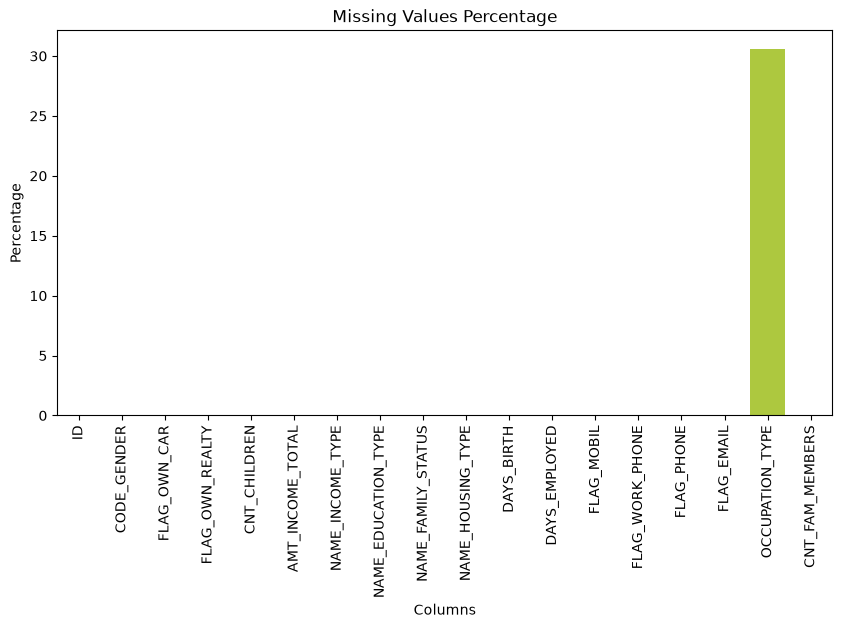

In [29]:
# ==========================================
# Missing Values Visualization
# ==========================================

plt.figure(figsize=(10,5))

sns.barplot(
    x=missing_percentage.index,
    y=missing_percentage.values,
    palette="viridis"
)

plt.xticks(rotation=90)

plt.title("Missing Values Percentage")

plt.xlabel("Columns")

plt.ylabel("Percentage")

plt.show()

In [30]:
# ==========================================
# Missing Values in Credit Dataset
# ==========================================

print("Missing Values in Credit Dataset")
print(credit_df.isnull().sum())

Missing Values in Credit Dataset
ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64


In [31]:
# ==========================================
# Missing Value Percentage
# ==========================================

credit_missing = ( credit_df.isnull().sum() /len(credit_df)) * 100
print(credit_missing)

ID                0.0
MONTHS_BALANCE    0.0
STATUS            0.0
dtype: float64


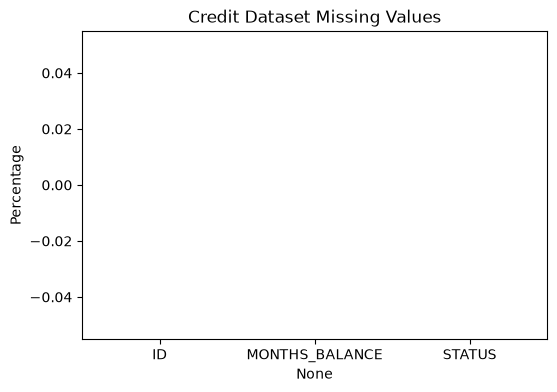

In [32]:
# ==========================================
# Credit Dataset Missing Values Graph
# ==========================================

plt.figure(figsize=(6,4))
sns.barplot(
    x=credit_missing.index,
    y=credit_missing.values,
    palette="Set2"
)

plt.title("Credit Dataset Missing Values")
plt.ylabel("Percentage")
plt.show()

In [33]:
# ==========================================
# Duplicate Records in Application Dataset
# ==========================================

print("Duplicate Records in Application Dataset")
print(application_df.duplicated().sum())

Duplicate Records in Application Dataset
0


In [34]:
# ==========================================
# Duplicate Percentage
# ==========================================

duplicate_percentage = (application_df.duplicated().sum() / len(application_df)) * 100
print("Duplicate Percentage: {:.4f}%".format(duplicate_percentage))

Duplicate Percentage: 0.0000%


In [35]:
# ==========================================
# Duplicate Records in Credit Dataset
# ==========================================

print("Duplicate Records in Credit Dataset")
print(credit_df.duplicated().sum())

Duplicate Records in Credit Dataset
0


In [36]:
# ==========================================
# Unique Occupation Types
# ==========================================

print("Unique Occupation Types")
print(application_df["OCCUPATION_TYPE"].value_counts())

Unique Occupation Types
OCCUPATION_TYPE
Laborers                 78240
Core staff               43007
Sales staff              41098
Managers                 35487
Drivers                  26090
High skill tech staff    17289
Accountants              15985
Medicine staff           13520
Cooking staff             8076
Security staff            7993
Cleaning staff            5845
Private service staff     3456
Low-skill Laborers        2140
Secretaries               2044
Waiters/barmen staff      1665
Realty agents             1041
HR staff                   774
IT staff                   604
Name: count, dtype: int64


In [37]:
# ==========================================
# Fill Missing Occupation Values
# ==========================================

application_df["OCCUPATION_TYPE"] = application_df["OCCUPATION_TYPE"].fillna("Unknown")

print("Missing Values After Filling")
print(application_df["OCCUPATION_TYPE"].isnull().sum())

Missing Values After Filling
0


In [38]:
# ==========================================
# Convert DAYS_BIRTH to Positive
# ==========================================

application_df["DAYS_BIRTH"] = application_df["DAYS_BIRTH"].abs()
print(application_df["DAYS_BIRTH"].head())

0    12005
1    12005
2    21474
3    19110
4    19110
Name: DAYS_BIRTH, dtype: int64


In [39]:
# ==========================================
# Convert DAYS_EMPLOYED to Positive
# ==========================================

application_df["DAYS_EMPLOYED"] = application_df["DAYS_EMPLOYED"].abs()
print(application_df["DAYS_EMPLOYED"].head())

0    4542
1    4542
2    1134
3    3051
4    3051
Name: DAYS_EMPLOYED, dtype: int64


In [40]:
# ==========================================
# Verify Missing Values
# ==========================================

print(application_df.isnull().sum())

ID                     0
CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
NAME_HOUSING_TYPE      0
DAYS_BIRTH             0
DAYS_EMPLOYED          0
FLAG_MOBIL             0
FLAG_WORK_PHONE        0
FLAG_PHONE             0
FLAG_EMAIL             0
OCCUPATION_TYPE        0
CNT_FAM_MEMBERS        0
dtype: int64


In [41]:
# ==========================================
# Unique Status Values
# ==========================================

print("Unique Credit Status Values")
print(credit_df["STATUS"].value_counts())

Unique Credit Status Values
STATUS
C    442031
0    383120
X    209230
1     11090
5      1693
2       868
3       320
4       223
Name: count, dtype: int64


In [42]:
# ==========================================
# Create Binary Target
# ==========================================

credit_df["TARGET"] = credit_df["STATUS"].apply(
    lambda x: 1 if x in ["2", "3", "4", "5"] else 0
)
print(credit_df.head())

        ID  MONTHS_BALANCE STATUS  TARGET
0  5001711               0      X       0
1  5001711              -1      0       0
2  5001711              -2      0       0
3  5001711              -3      0       0
4  5001712               0      C       0


In [43]:
# ==========================================
# Target Distribution
# ==========================================

print("Target Distribution")
print(credit_df["TARGET"].value_counts())

Target Distribution
TARGET
0    1045471
1       3104
Name: count, dtype: int64


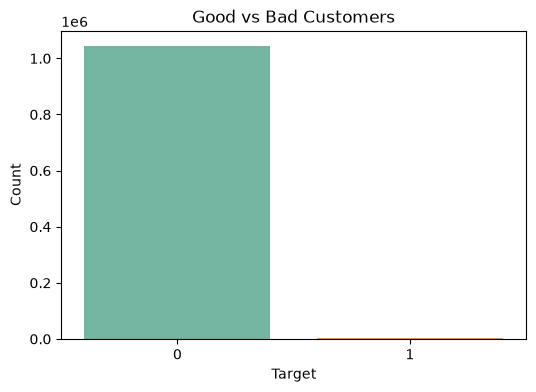

In [44]:
# ==========================================
# Target Distribution Plot
# ==========================================

plt.figure(figsize=(6, 4))
sns.countplot(
    data=credit_df,
    x="TARGET",
    palette="Set2"
)

plt.title("Good vs Bad Customers")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

In [45]:
# ==========================================
# Aggregate Target by Customer
# ==========================================

customer_target = (credit_df.groupby("ID")["TARGET"].max().reset_index())
print(customer_target.head())

        ID  TARGET
0  5001711       0
1  5001712       0
2  5001713       0
3  5001714       0
4  5001715       0


In [46]:
# ==========================================
# Aggregated Dataset Shape
# ==========================================

print("Customer Target Shape")
print(customer_target.shape)

print("\nTarget Distribution")
print(customer_target["TARGET"].value_counts())

Customer Target Shape
(45985, 2)

Target Distribution
TARGET
0    45318
1      667
Name: count, dtype: int64


In [47]:
# ===================================================
# Merge Application Dataset with Customer Target
# ===================================================

final_df = application_df.merge(
    customer_target,
    on="ID",
    how="inner"
)
print("Datasets Merged Successfully")

Datasets Merged Successfully


In [48]:
# ===================================================
# Preview Final Dataset
# ===================================================

final_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,12005,4542,1,1,0,0,Unknown,2.0,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,12005,4542,1,1,0,0,Unknown,2.0,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,21474,1134,1,0,0,0,Security staff,2.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,19110,3051,1,0,1,1,Sales staff,1.0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,19110,3051,1,0,1,1,Sales staff,1.0,0


In [49]:
# ===================================================
# Final Dataset Shape
# ===================================================

print("Final Dataset Shape")
print(final_df.shape)

Final Dataset Shape
(36457, 19)


In [50]:
# ===================================================
# Final Dataset Information
# ===================================================

final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   CODE_GENDER          36457 non-null  str    
 2   FLAG_OWN_CAR         36457 non-null  str    
 3   FLAG_OWN_REALTY      36457 non-null  str    
 4   CNT_CHILDREN         36457 non-null  int64  
 5   AMT_INCOME_TOTAL     36457 non-null  float64
 6   NAME_INCOME_TYPE     36457 non-null  str    
 7   NAME_EDUCATION_TYPE  36457 non-null  str    
 8   NAME_FAMILY_STATUS   36457 non-null  str    
 9   NAME_HOUSING_TYPE    36457 non-null  str    
 10  DAYS_BIRTH           36457 non-null  int64  
 11  DAYS_EMPLOYED        36457 non-null  int64  
 12  FLAG_MOBIL           36457 non-null  int64  
 13  FLAG_WORK_PHONE      36457 non-null  int64  
 14  FLAG_PHONE           36457 non-null  int64  
 15  FLAG_EMAIL           36457 non-null  int64  
 1

In [51]:
# ===================================================
# Missing Values After Merge
# ===================================================

print(final_df.isnull().sum())

ID                     0
CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
NAME_HOUSING_TYPE      0
DAYS_BIRTH             0
DAYS_EMPLOYED          0
FLAG_MOBIL             0
FLAG_WORK_PHONE        0
FLAG_PHONE             0
FLAG_EMAIL             0
OCCUPATION_TYPE        0
CNT_FAM_MEMBERS        0
TARGET                 0
dtype: int64


In [52]:
# ===================================================
# Target Distribution
# ===================================================

print(final_df["TARGET"].value_counts())

TARGET
0    35841
1      616
Name: count, dtype: int64


In [53]:
# ===================================================
# Target Percentage
# ===================================================

target_percent = ( final_df["TARGET"].value_counts(normalize=True) * 100 )
print(target_percent)

TARGET
0    98.310338
1     1.689662
Name: proportion, dtype: float64


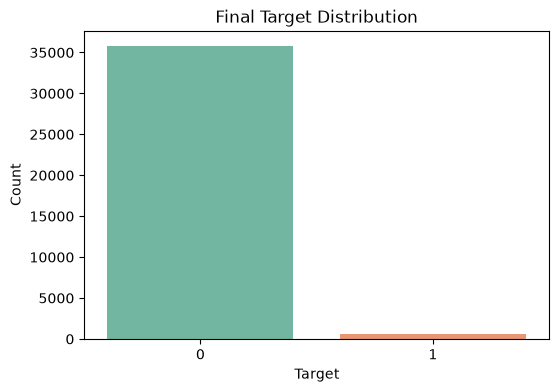

In [54]:
# ===================================================
# Target Distribution Plot
# ===================================================

plt.figure(figsize=(6,4))
sns.countplot(
    data=final_df,
    x="TARGET",
    palette="Set2"
)

plt.title("Final Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

In [55]:
# =====================================================
# Create Age Feature
# =====================================================

final_df["AGE"] = (final_df["DAYS_BIRTH"] / 365).astype(int)
print(final_df[["DAYS_BIRTH", "AGE"]].head())

   DAYS_BIRTH  AGE
0       12005   32
1       12005   32
2       21474   58
3       19110   52
4       19110   52


In [56]:
# =====================================================
# Create Employment Years
# =====================================================

final_df["EMPLOYED_YEARS"] = (final_df["DAYS_EMPLOYED"] / 365).astype(int)
print(final_df[["DAYS_EMPLOYED", "EMPLOYED_YEARS"]].head())

   DAYS_EMPLOYED  EMPLOYED_YEARS
0           4542              12
1           4542              12
2           1134               3
3           3051               8
4           3051               8


In [57]:
# =====================================================
# Income Per Family Member
# =====================================================

final_df["INCOME_PER_PERSON"] = ( final_df["AMT_INCOME_TOTAL"] / final_df["CNT_FAM_MEMBERS"] )

print(final_df[
    ["AMT_INCOME_TOTAL",
     "CNT_FAM_MEMBERS",
     "INCOME_PER_PERSON"]
].head())

   AMT_INCOME_TOTAL  CNT_FAM_MEMBERS  INCOME_PER_PERSON
0          427500.0              2.0           213750.0
1          427500.0              2.0           213750.0
2          112500.0              2.0            56250.0
3          270000.0              1.0           270000.0
4          270000.0              1.0           270000.0


In [58]:
# =====================================================
# Children Ratio
# =====================================================

final_df["CHILD_RATIO"] = ( final_df["CNT_CHILDREN"] / final_df["CNT_FAM_MEMBERS"] )

print(final_df[
    ["CNT_CHILDREN",
     "CNT_FAM_MEMBERS",
     "CHILD_RATIO"]
].head())

   CNT_CHILDREN  CNT_FAM_MEMBERS  CHILD_RATIO
0             0              2.0          0.0
1             0              2.0          0.0
2             0              2.0          0.0
3             0              1.0          0.0
4             0              1.0          0.0


In [59]:
# =====================================================
# Newly Created Features
# =====================================================

print(final_df[
    [
        "AGE",
        "EMPLOYED_YEARS",
        "INCOME_PER_PERSON",
        "CHILD_RATIO"
    ]
].head())

   AGE  EMPLOYED_YEARS  INCOME_PER_PERSON  CHILD_RATIO
0   32              12           213750.0          0.0
1   32              12           213750.0          0.0
2   58               3            56250.0          0.0
3   52               8           270000.0          0.0
4   52               8           270000.0          0.0


In [60]:
# =====================================================
# Statistics of New Features
# =====================================================

print(
    final_df[
        [
            "AGE",
            "EMPLOYED_YEARS",
            "INCOME_PER_PERSON",
            "CHILD_RATIO"
        ]
    ].describe()
)

                AGE  EMPLOYED_YEARS  INCOME_PER_PERSON   CHILD_RATIO
count  36457.000000    36457.000000       36457.000000  36457.000000
mean      43.260334      173.895000      100554.765560      0.128552
std       11.510414      371.641572       72678.927101      0.200407
min       20.000000        0.000000        5625.000000      0.000000
25%       34.000000        3.000000       56250.000000      0.000000
50%       42.000000        6.000000       78750.000000      0.000000
75%       53.000000       15.000000      123750.000000      0.333333
max       68.000000     1000.000000      900000.000000      2.000000


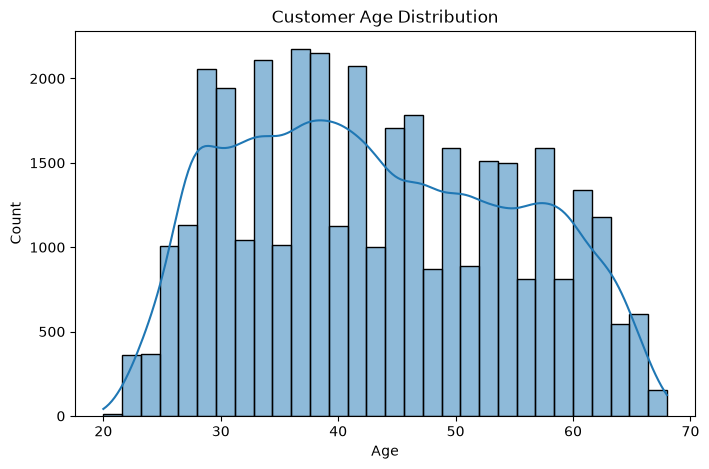

In [61]:
# =====================================================
# Age Distribution
# =====================================================

plt.figure(figsize=(8,5))
sns.histplot(
    final_df["AGE"],
    bins=30,
    kde=True
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

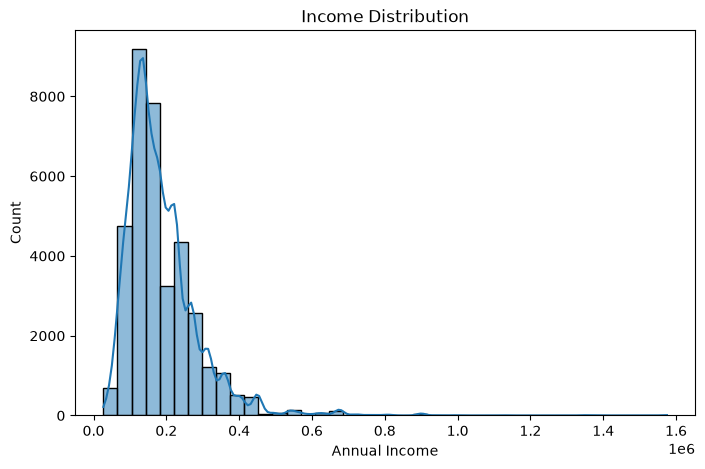

In [62]:
# =====================================================
# Income Distribution
# =====================================================

plt.figure(figsize=(8,5))
sns.histplot(
    final_df["AMT_INCOME_TOTAL"],
    bins=40,
    kde=True
)

plt.title("Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Count")
plt.show()

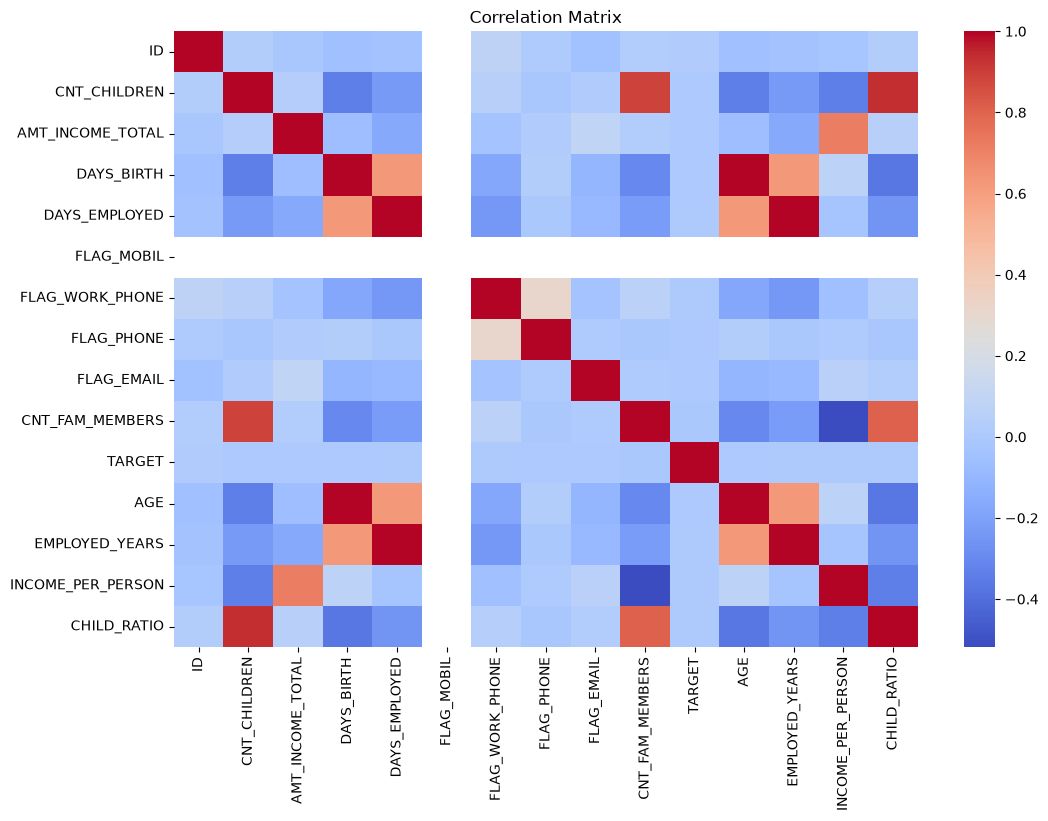

In [63]:
# =====================================================
# Correlation Matrix
# =====================================================

numeric_columns = final_df.select_dtypes( include=["int64", "float64"] )
corr = numeric_columns.corr()

plt.figure(figsize=(12,8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix")
plt.show()

In [64]:
# ==========================================================
# Categorical Columns
# ==========================================================

categorical_columns = final_df.select_dtypes(include="object").columns
print("Categorical Columns")
print(categorical_columns)

Categorical Columns
Index(['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE',
       'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
       'OCCUPATION_TYPE'],
      dtype='str')


In [65]:
# ==========================================================
# Unique Values in Each Categorical Column
# ==========================================================

for column in categorical_columns:
    print("\n", "=" * 50)
    print(column)
    print(final_df[column].value_counts())


CODE_GENDER
CODE_GENDER
F    24430
M    12027
Name: count, dtype: int64

FLAG_OWN_CAR
FLAG_OWN_CAR
N    22614
Y    13843
Name: count, dtype: int64

FLAG_OWN_REALTY
FLAG_OWN_REALTY
Y    24506
N    11951
Name: count, dtype: int64

NAME_INCOME_TYPE
NAME_INCOME_TYPE
Working                 18819
Commercial associate     8490
Pensioner                6152
State servant            2985
Student                    11
Name: count, dtype: int64

NAME_EDUCATION_TYPE
NAME_EDUCATION_TYPE
Secondary / secondary special    24777
Higher education                  9864
Incomplete higher                 1410
Lower secondary                    374
Academic degree                     32
Name: count, dtype: int64

NAME_FAMILY_STATUS
NAME_FAMILY_STATUS
Married                 25048
Single / not married     4829
Civil marriage           2945
Separated                2103
Widow                    1532
Name: count, dtype: int64

NAME_HOUSING_TYPE
NAME_HOUSING_TYPE
House / apartment      32548
With parents     

In [66]:
# ==========================================================
# Import Label Encoder
# ==========================================================

from sklearn.preprocessing import LabelEncoder

In [67]:
label_encoders = {}

categorical_columns = [
    'CODE_GENDER',
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE'
]

for col in categorical_columns:
    le = LabelEncoder()
    final_df[col] = le.fit_transform(final_df[col])
    label_encoders[col] = le

print("Categorical Features Encoded Successfully")

Categorical Features Encoded Successfully


In [68]:
# ==========================================================
# Verify Data Types
# ==========================================================

print(final_df.dtypes)

ID                       int64
CODE_GENDER              int64
FLAG_OWN_CAR             int64
FLAG_OWN_REALTY          int64
CNT_CHILDREN             int64
AMT_INCOME_TOTAL       float64
NAME_INCOME_TYPE         int64
NAME_EDUCATION_TYPE      int64
NAME_FAMILY_STATUS       int64
NAME_HOUSING_TYPE        int64
DAYS_BIRTH               int64
DAYS_EMPLOYED            int64
FLAG_MOBIL               int64
FLAG_WORK_PHONE          int64
FLAG_PHONE               int64
FLAG_EMAIL               int64
OCCUPATION_TYPE          int64
CNT_FAM_MEMBERS        float64
TARGET                   int64
AGE                      int64
EMPLOYED_YEARS           int64
INCOME_PER_PERSON      float64
CHILD_RATIO            float64
dtype: object


In [69]:
# ==========================================================
# Preview Encoded Dataset
# ==========================================================

final_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET,AGE,EMPLOYED_YEARS,INCOME_PER_PERSON,CHILD_RATIO
0,5008804,1,1,1,0,427500.0,4,1,0,4,...,1,0,0,17,2.0,0,32,12,213750.0,0.0
1,5008805,1,1,1,0,427500.0,4,1,0,4,...,1,0,0,17,2.0,0,32,12,213750.0,0.0
2,5008806,1,1,1,0,112500.0,4,4,1,1,...,0,0,0,16,2.0,0,58,3,56250.0,0.0
3,5008808,0,0,1,0,270000.0,0,4,3,1,...,0,1,1,14,1.0,0,52,8,270000.0,0.0
4,5008809,0,0,1,0,270000.0,0,4,3,1,...,0,1,1,14,1.0,0,52,8,270000.0,0.0


In [70]:
# ==========================================================
# Dataset Information
# ==========================================================

final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   CODE_GENDER          36457 non-null  int64  
 2   FLAG_OWN_CAR         36457 non-null  int64  
 3   FLAG_OWN_REALTY      36457 non-null  int64  
 4   CNT_CHILDREN         36457 non-null  int64  
 5   AMT_INCOME_TOTAL     36457 non-null  float64
 6   NAME_INCOME_TYPE     36457 non-null  int64  
 7   NAME_EDUCATION_TYPE  36457 non-null  int64  
 8   NAME_FAMILY_STATUS   36457 non-null  int64  
 9   NAME_HOUSING_TYPE    36457 non-null  int64  
 10  DAYS_BIRTH           36457 non-null  int64  
 11  DAYS_EMPLOYED        36457 non-null  int64  
 12  FLAG_MOBIL           36457 non-null  int64  
 13  FLAG_WORK_PHONE      36457 non-null  int64  
 14  FLAG_PHONE           36457 non-null  int64  
 15  FLAG_EMAIL           36457 non-null  int64  
 1

In [71]:
# ==========================================================
# Numerical Columns
# ==========================================================

numerical_columns = final_df.select_dtypes(include=["int64", "float64"]).columns
print("Numerical Columns")
print(numerical_columns)

Numerical Columns
Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'TARGET', 'AGE',
       'EMPLOYED_YEARS', 'INCOME_PER_PERSON', 'CHILD_RATIO'],
      dtype='str')


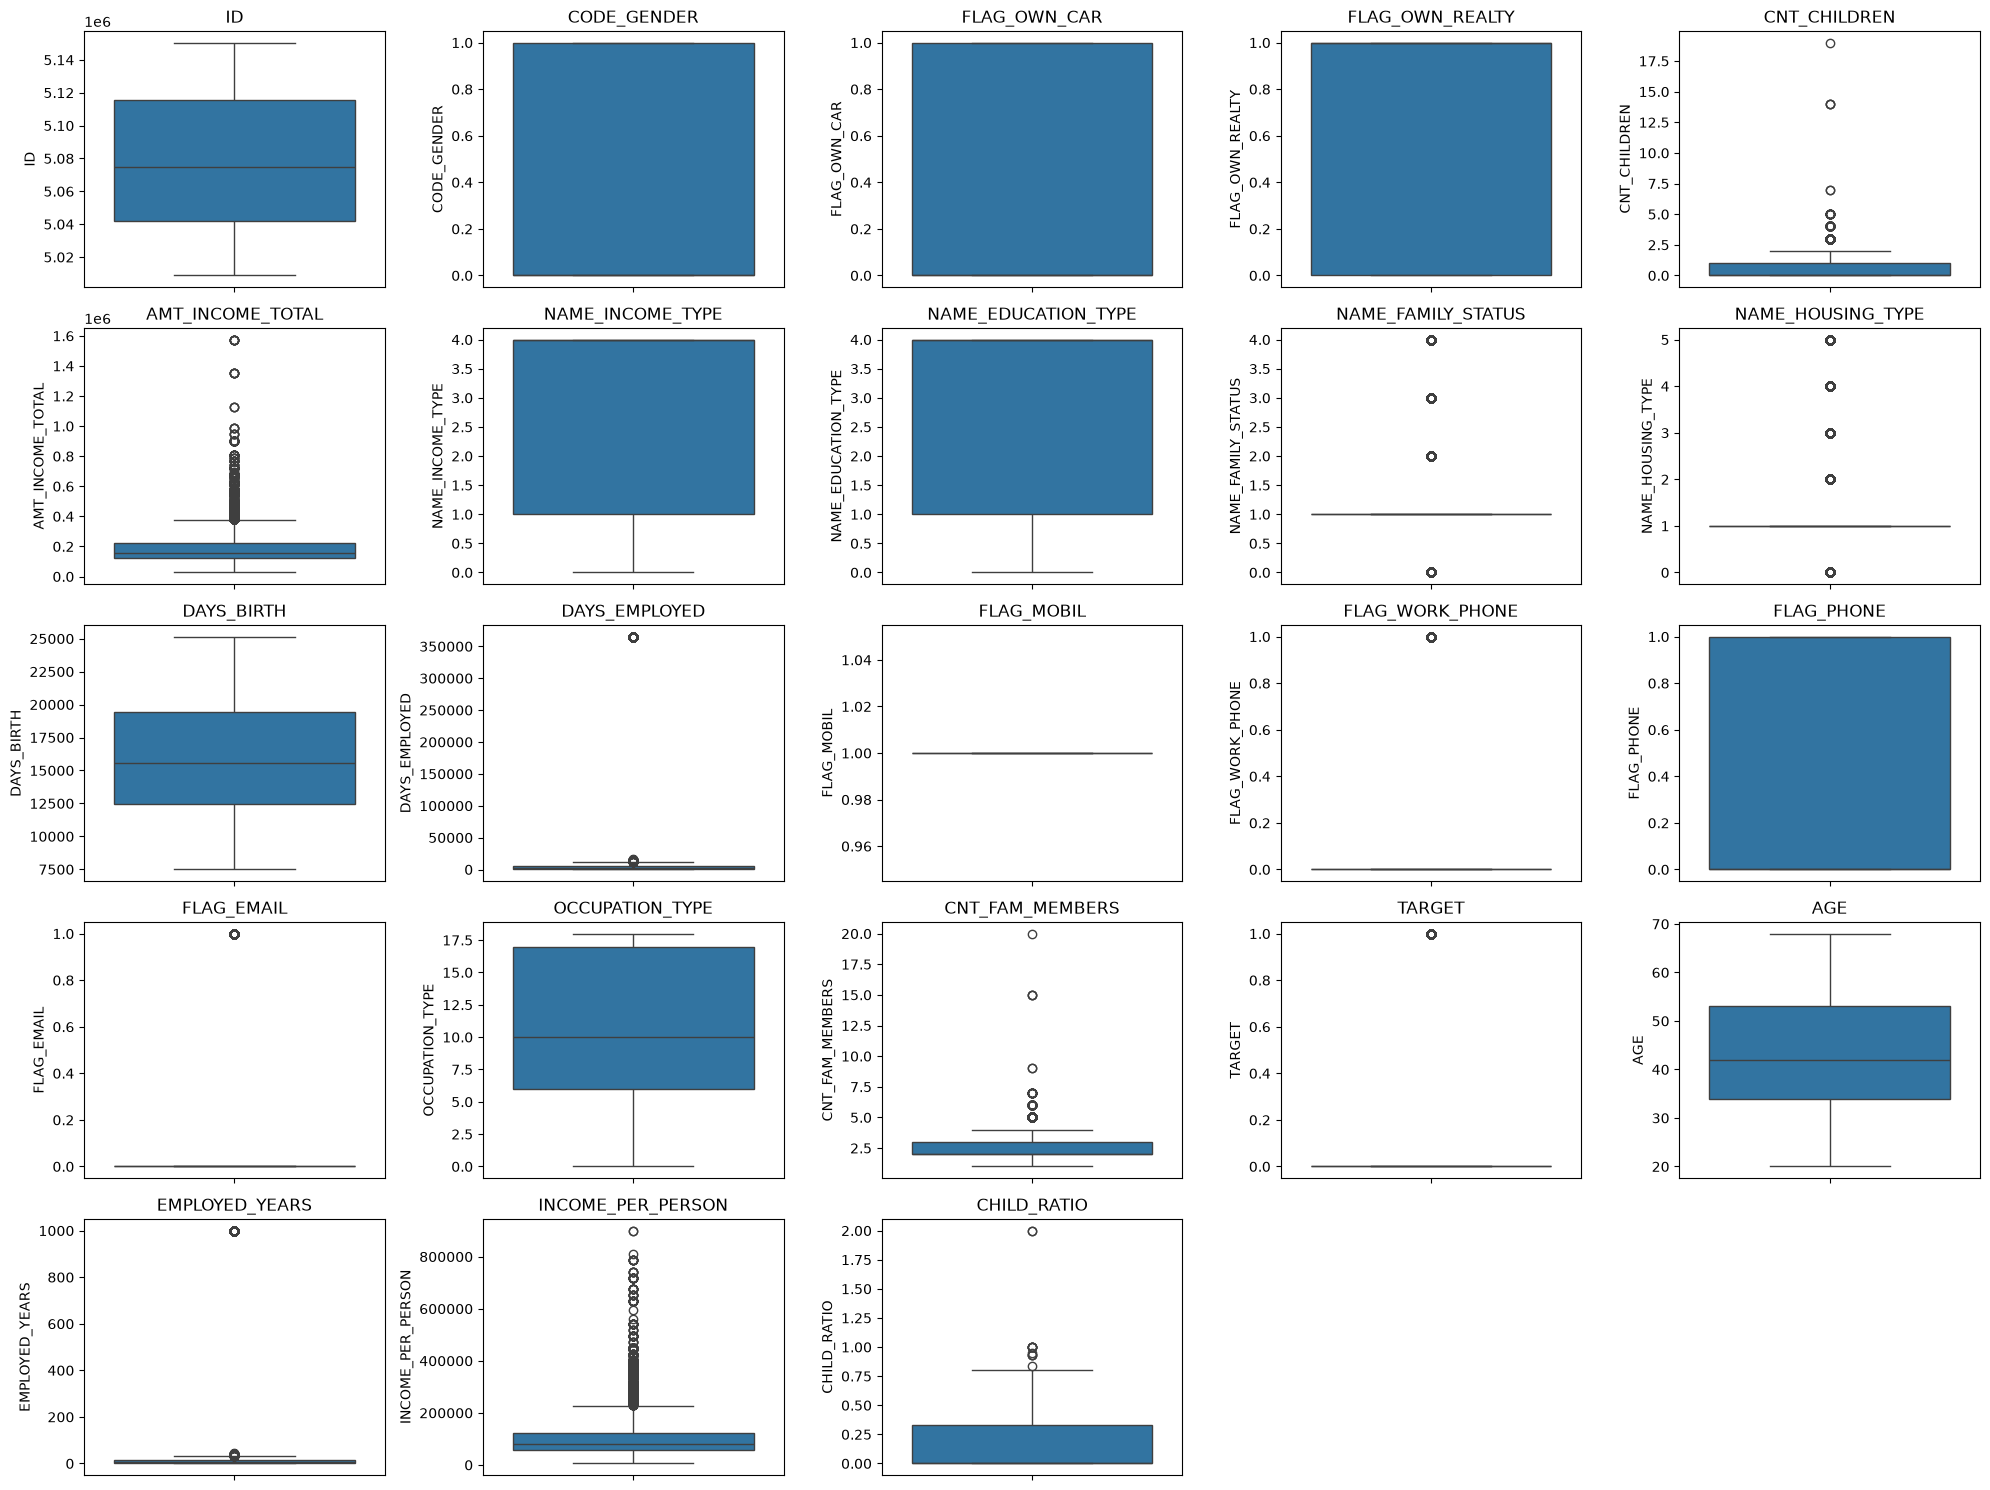

In [72]:
# ==========================================================
# Boxplots Before Outlier Treatment
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20,15))
for i, column in enumerate(numerical_columns, 1):
    plt.subplot(5,5,i)
    sns.boxplot(y=final_df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

In [73]:
# ==========================================================
# Maximum Employment Years
# ==========================================================

print("Maximum Employment Years")
print(final_df["EMPLOYED_YEARS"].max())

Maximum Employment Years
1000


In [74]:
# ==========================================================
# Replace Unrealistic Employment Years
# ==========================================================

final_df.loc[
    final_df["EMPLOYED_YEARS"] > 80,
    "EMPLOYED_YEARS"
] = final_df["EMPLOYED_YEARS"].median()

print("Maximum Employment Years After Cleaning")
print(final_df["EMPLOYED_YEARS"].max())

Maximum Employment Years After Cleaning
43


In [75]:
# ==========================================================
# IQR Outlier Treatment Function
# ==========================================================

def treat_outliers(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower, upper)
    return df

In [76]:
# ==========================================================
# Apply IQR Treatment
# ==========================================================

outlier_columns = [
    "AMT_INCOME_TOTAL",
    "AGE",
    "EMPLOYED_YEARS",
    "INCOME_PER_PERSON",
    "CHILD_RATIO"
]

for column in outlier_columns:
    final_df = treat_outliers(final_df, column)
print("Outlier Treatment Completed")

Outlier Treatment Completed


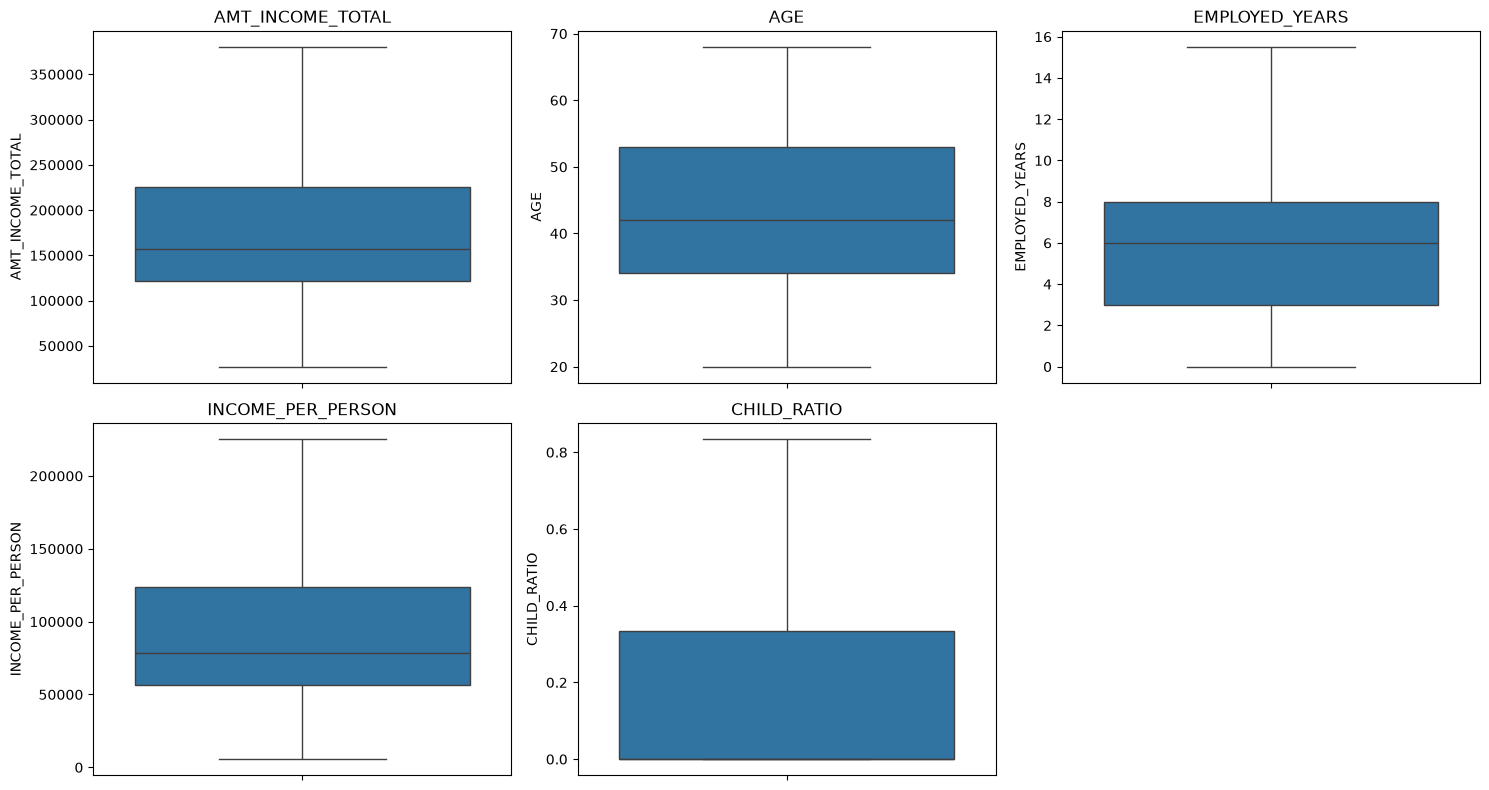

In [77]:
# ==========================================================
# Boxplots After Treatment
# ==========================================================

plt.figure(figsize=(15,8))

for i, column in enumerate(outlier_columns, 1):
    plt.subplot(2,3,i)
    sns.boxplot(y=final_df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

In [78]:
# ==========================================================
# Final Dataset Columns
# ==========================================================

print("Final Dataset Columns")
print(final_df.columns)

Final Dataset Columns
Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'TARGET', 'AGE',
       'EMPLOYED_YEARS', 'INCOME_PER_PERSON', 'CHILD_RATIO'],
      dtype='str')


In [79]:
# ==========================================================
# Create Features (X) and Target (y)
# ==========================================================

X = final_df.drop(columns=["ID", "TARGET"])
y = final_df["TARGET"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (36457, 21)
Target Shape   : (36457,)


In [80]:
# ==========================================================
# Preview Features
# ==========================================================

X.head()

# ==========================================================
# Preview Target
# ==========================================================

y.head()

0    0
1    0
2    0
3    0
4    0
Name: TARGET, dtype: int64

In [81]:
# ==========================================================
# Target Distribution
# ==========================================================

print("Target Distribution")
print(y.value_counts())

print("\nTarget Percentage")
print(y.value_counts(normalize=True) * 100)

Target Distribution
TARGET
0    35841
1      616
Name: count, dtype: int64

Target Percentage
TARGET
0    98.310338
1     1.689662
Name: proportion, dtype: float64


In [82]:
# ==========================================================
# Number of Features
# ==========================================================

print("Total Features :", X.shape[1])

Total Features : 21


In [83]:
# ==========================================================
# Feature Names
# ==========================================================

print(X.columns)

Index(['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'AGE',
       'EMPLOYED_YEARS', 'INCOME_PER_PERSON', 'CHILD_RATIO'],
      dtype='str')


In [84]:
# ==========================================================
# Import Train-Test Split
# ==========================================================

from sklearn.model_selection import train_test_split

In [85]:
# ==========================================================
# Train-Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Dataset Split Successfully")

Dataset Split Successfully


In [86]:
# ==========================================================
# Shapes of Train and Test Sets
# ==========================================================

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (29165, 21)
X_test  : (7292, 21)
y_train : (29165,)
y_test  : (7292,)


In [87]:
# ==========================================================
# Training Target Distribution
# ==========================================================

print("Training Set")
print(y_train.value_counts())

print("\nPercentage")
print(y_train.value_counts(normalize=True) * 100)

Training Set
TARGET
0    28672
1      493
Name: count, dtype: int64

Percentage
TARGET
0    98.309618
1     1.690382
Name: proportion, dtype: float64


In [88]:
# ==========================================================
# Import StandardScaler
# ==========================================================

from sklearn.preprocessing import StandardScaler

In [89]:
# ==========================================================
# Numerical Columns for Scaling
# ==========================================================

scale_columns = [
    "AMT_INCOME_TOTAL",
    "CNT_FAM_MEMBERS",
    "AGE",
    "EMPLOYED_YEARS",
    "INCOME_PER_PERSON",
    "CHILD_RATIO"
]

print("Columns to Scale")
print(scale_columns)

Columns to Scale
['AMT_INCOME_TOTAL', 'CNT_FAM_MEMBERS', 'AGE', 'EMPLOYED_YEARS', 'INCOME_PER_PERSON', 'CHILD_RATIO']


In [90]:
# ==========================================================
# Create StandardScaler
# ==========================================================

scaler = StandardScaler()

# ==========================================================
# Scale Training Data
# ==========================================================

X_train[scale_columns] = scaler.fit_transform( X_train[scale_columns] )
print("Training Data Scaled Successfully")

Training Data Scaled Successfully


In [91]:
# ==========================================================
# Scale Testing Data
# ==========================================================

X_test[scale_columns] = scaler.transform(X_test[scale_columns])
print("Testing Data Scaled Successfully")

Testing Data Scaled Successfully


In [92]:
# ==========================================================
# Verify Scaling
# ==========================================================

print(X_train[scale_columns].describe().round(2))

       AMT_INCOME_TOTAL  CNT_FAM_MEMBERS       AGE  EMPLOYED_YEARS  \
count          29165.00         29165.00  29165.00        29165.00   
mean              -0.00             0.00      0.00           -0.00   
std                1.00             1.00      1.00            1.00   
min               -1.91            -1.31     -2.02           -1.39   
25%               -0.74            -0.22     -0.80           -0.70   
50%               -0.30            -0.22     -0.11           -0.02   
75%                0.54             0.87      0.85            0.43   
max                2.45            19.43      2.15            2.14   

       INCOME_PER_PERSON  CHILD_RATIO  
count           29165.00     29165.00  
mean               -0.00        -0.00  
std                 1.00         1.00  
min                -1.62        -0.64  
25%                -0.71        -0.64  
50%                -0.31        -0.64  
75%                 0.50         1.03  
max                 2.32         3.54  


In [93]:
# ==========================================================
# Import SMOTE
# ==========================================================

from imblearn.over_sampling import SMOTE

In [94]:
# ==========================================================
# Class Distribution Before SMOTE
# ==========================================================

print("Before SMOTE")
print(y_train.value_counts())

print("\nPercentage")
print(y_train.value_counts(normalize=True) * 100)

Before SMOTE
TARGET
0    28672
1      493
Name: count, dtype: int64

Percentage
TARGET
0    98.309618
1     1.690382
Name: proportion, dtype: float64


In [95]:
# ==========================================================
# Apply SMOTE
# ==========================================================

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)
print("SMOTE Applied Successfully")

SMOTE Applied Successfully


In [96]:
# ==========================================================
# Dataset Shapes After SMOTE
# ==========================================================

print("X_train Before :", X_train.shape)
print("X_train After  :", X_train_smote.shape)

print()

print("y_train Before :", y_train.shape)
print("y_train After  :", y_train_smote.shape)

X_train Before : (29165, 21)
X_train After  : (57344, 21)

y_train Before : (29165,)
y_train After  : (57344,)


In [97]:
# ==========================================================
# Class Distribution After SMOTE
# ==========================================================

print("After SMOTE")
print(y_train_smote.value_counts())

print("\nPercentage")
print(y_train_smote.value_counts(normalize=True) * 100)

After SMOTE
TARGET
0    28672
1    28672
Name: count, dtype: int64

Percentage
TARGET
0    50.0
1    50.0
Name: proportion, dtype: float64


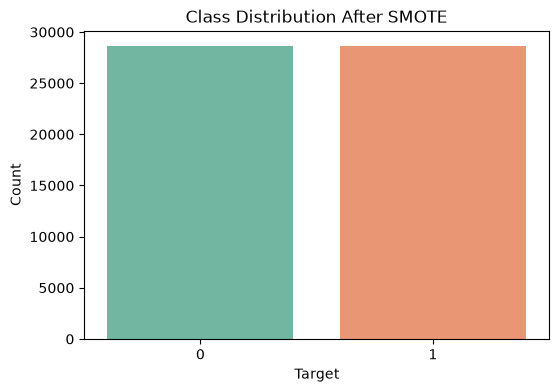

In [98]:
# ==========================================================
# SMOTE Class Distribution Plot
# ==========================================================

plt.figure(figsize=(6,4))
sns.countplot(
    x=y_train_smote,
    palette="Set2"
)

plt.title("Class Distribution After SMOTE")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

In [99]:
# ==========================================================
# Import Logistic Regression
# ==========================================================

from sklearn.linear_model import LogisticRegression

In [100]:
# ==========================================================
# Create Logistic Regression Model
# ==========================================================

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [101]:
# ==========================================================
# Train Logistic Regression Model
# ==========================================================

logistic_model.fit(
    X_train_smote,
    y_train_smote
)
print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


In [102]:
# ==========================================================
# Predictions
# ==========================================================

y_pred_lr = logistic_model.predict(X_test)
print(y_pred_lr[:10])

[0 0 0 0 0 0 0 1 0 1]


In [103]:
# ==========================================================
# Accuracy Score
# ==========================================================

from sklearn.metrics import accuracy_score

accuracy_lr = accuracy_score(
    y_test,
    y_pred_lr
)
print("Logistic Regression Accuracy : {:.2f}%".format(accuracy_lr * 100))

Logistic Regression Accuracy : 70.56%


In [104]:
# ==========================================================
# Confusion Matrix
# ==========================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_lr
)
print(cm)

[[5116 2053]
 [  94   29]]


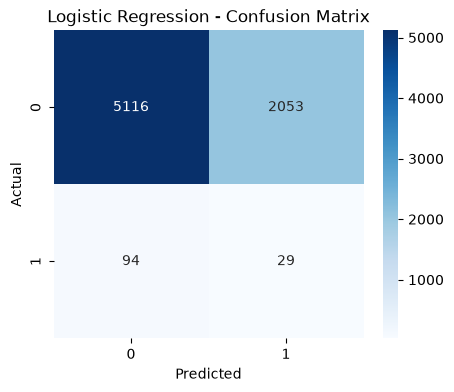

In [105]:
# ==========================================================
# Confusion Matrix Plot
# ==========================================================

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [106]:
# ==========================================================
# Classification Report
# ==========================================================

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.98      0.71      0.83      7169
           1       0.01      0.24      0.03       123

    accuracy                           0.71      7292
   macro avg       0.50      0.47      0.43      7292
weighted avg       0.97      0.71      0.81      7292



In [107]:
# ==========================================================
# Import Decision Tree Classifier
# ==========================================================

from sklearn.tree import DecisionTreeClassifier

In [108]:
# ==========================================================
# Create Decision Tree Model
# ==========================================================

decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10
)
print("Decision Tree Model Created Successfully")

Decision Tree Model Created Successfully


In [109]:
# ==========================================================
# Train Decision Tree
# ==========================================================

decision_tree.fit(
    X_train_smote,
    y_train_smote
)
print("Decision Tree Trained Successfully")

Decision Tree Trained Successfully


In [110]:
# ==========================================================
# Make Predictions
# ==========================================================

y_pred_dt = decision_tree.predict(X_test)
print(y_pred_dt[:10])

[0 0 1 0 0 0 1 1 0 0]


In [111]:
# ==========================================================
# Accuracy
# ==========================================================

from sklearn.metrics import accuracy_score

accuracy_dt = accuracy_score(
    y_test,
    y_pred_dt
)
print("Decision Tree Accuracy : {:.2f}%".format(accuracy_dt*100))

Decision Tree Accuracy : 80.27%


In [112]:
# ==========================================================
# Confusion Matrix
# ==========================================================

from sklearn.metrics import confusion_matrix

cm_dt = confusion_matrix(
    y_test,
    y_pred_dt
)
print(cm_dt)

[[5811 1358]
 [  81   42]]


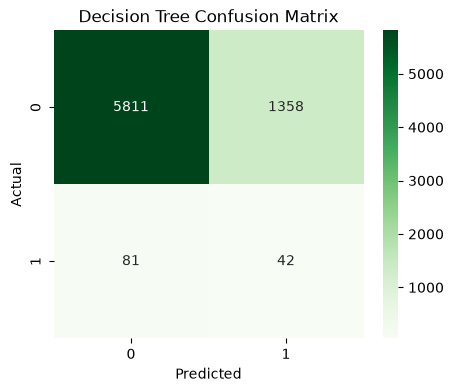

In [113]:
# ==========================================================
# Decision Tree Confusion Matrix
# ==========================================================

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [114]:
# ==========================================================
# Classification Report
# ==========================================================

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_dt
    )
)

              precision    recall  f1-score   support

           0       0.99      0.81      0.89      7169
           1       0.03      0.34      0.06       123

    accuracy                           0.80      7292
   macro avg       0.51      0.58      0.47      7292
weighted avg       0.97      0.80      0.88      7292



In [115]:
# ==========================================================
# Save Model Results
# ==========================================================

model_results = {}

model_results["Logistic Regression"] = accuracy_lr
model_results["Decision Tree"] = accuracy_dt
print(model_results)

{'Logistic Regression': 0.7055677454744926, 'Decision Tree': 0.8026604498080088}


In [116]:
# ==========================================================
# Import Random Forest Classifier
# ==========================================================

from sklearn.ensemble import RandomForestClassifier

In [117]:
# ==========================================================
# Create Random Forest Model
# ==========================================================

random_forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

print("Random Forest Model Created Successfully")

Random Forest Model Created Successfully


In [118]:
# ==========================================================
# Train Random Forest Model
# ==========================================================

random_forest.fit(
    X_train_smote,
    y_train_smote
)
print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [119]:
# ==========================================================
# Random Forest Predictions
# ==========================================================

y_pred_rf = random_forest.predict(X_test)
print(y_pred_rf[:10])

[0 0 0 0 0 0 0 0 0 0]


In [120]:
# ==========================================================
# Random Forest Accuracy
# ==========================================================

accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)
print("Random Forest Accuracy : {:.2f}%".format(accuracy_rf * 100))

Random Forest Accuracy : 96.74%


In [121]:
# ==========================================================
# Confusion Matrix
# ==========================================================

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)
print(cm_rf)

[[7029  140]
 [  98   25]]


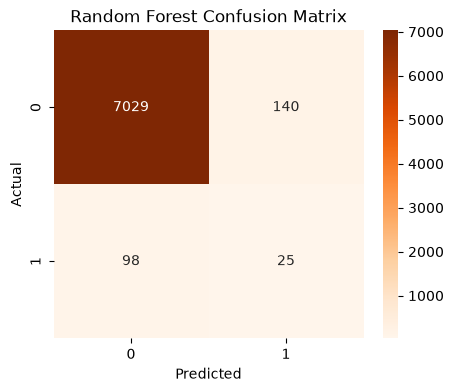

In [122]:
# ==========================================================
# Random Forest Confusion Matrix
# ==========================================================

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [123]:
# ==========================================================
# Classification Report
# ==========================================================

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      7169
           1       0.15      0.20      0.17       123

    accuracy                           0.97      7292
   macro avg       0.57      0.59      0.58      7292
weighted avg       0.97      0.97      0.97      7292



In [124]:
# ==========================================================
# Update Model Results
# ==========================================================

model_results["Random Forest"] = accuracy_rf
print(model_results)

{'Logistic Regression': 0.7055677454744926, 'Decision Tree': 0.8026604498080088, 'Random Forest': 0.9673614920460779}


In [125]:
# ==========================================================
# Import Gradient Boosting Classifier
# ==========================================================

from sklearn.ensemble import GradientBoostingClassifier

In [126]:
# ==========================================================
# Create Gradient Boosting Model
# ==========================================================

gradient_boost = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
print("Gradient Boosting Model Created Successfully")

Gradient Boosting Model Created Successfully


In [127]:
# ==========================================================
# Train Gradient Boosting Model
# ==========================================================

gradient_boost.fit(
    X_train_smote,
    y_train_smote
)
print("Gradient Boosting Model Trained Successfully")

Gradient Boosting Model Trained Successfully


In [128]:
# ==========================================================
# Make Predictions
# ==========================================================

y_pred_gb = gradient_boost.predict(X_test)
print(y_pred_gb[:10])

[0 0 0 0 0 0 0 1 0 0]


In [129]:
# ==========================================================
# Accuracy Score
# ==========================================================

accuracy_gb = accuracy_score(
    y_test,
    y_pred_gb
)
print("Gradient Boosting Accuracy : {:.2f}%".format(accuracy_gb * 100))

Gradient Boosting Accuracy : 95.95%


In [130]:
# ==========================================================
# Confusion Matrix
# ==========================================================

cm_gb = confusion_matrix(
    y_test,
    y_pred_gb
)
print(cm_gb)

[[6980  189]
 [ 106   17]]


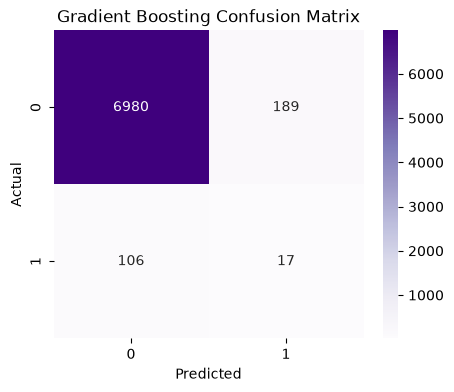

In [131]:
# ==========================================================
# Gradient Boosting Confusion Matrix
# ==========================================================

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_gb,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [132]:
# ==========================================================
# Classification Report
# ==========================================================

print(
    classification_report(
        y_test,
        y_pred_gb
    )
)

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      7169
           1       0.08      0.14      0.10       123

    accuracy                           0.96      7292
   macro avg       0.53      0.56      0.54      7292
weighted avg       0.97      0.96      0.96      7292



In [133]:
# ==========================================================
# Update Model Results
# ==========================================================

model_results["Gradient Boosting"] = accuracy_gb
print(model_results)

{'Logistic Regression': 0.7055677454744926, 'Decision Tree': 0.8026604498080088, 'Random Forest': 0.9673614920460779, 'Gradient Boosting': 0.9595447065277016}


In [134]:
# ==========================================================
# Automatic Model Evaluation Function
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(model_name, y_true, y_pred):

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0)
    }

In [135]:
# ==========================================================
# Collect Results
# ==========================================================

results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        y_pred_lr
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        y_pred_dt
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        y_pred_rf
    )
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        y_pred_gb
    )
)

In [136]:
comparison_df = pd.DataFrame(results)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.705568,0.013929,0.235772,0.026304
1,Decision Tree,0.802660,0.030000,0.341463,0.055154
2,Random Forest,0.967361,0.151515,0.203252,0.173611
3,Gradient Boosting,0.959545,0.082524,0.138211,0.103343


In [137]:
comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
)
comparison_df.reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.967361,0.151515,0.203252,0.173611
1,Gradient Boosting,0.959545,0.082524,0.138211,0.103343
2,Decision Tree,0.802660,0.030000,0.341463,0.055154
3,Logistic Regression,0.705568,0.013929,0.235772,0.026304


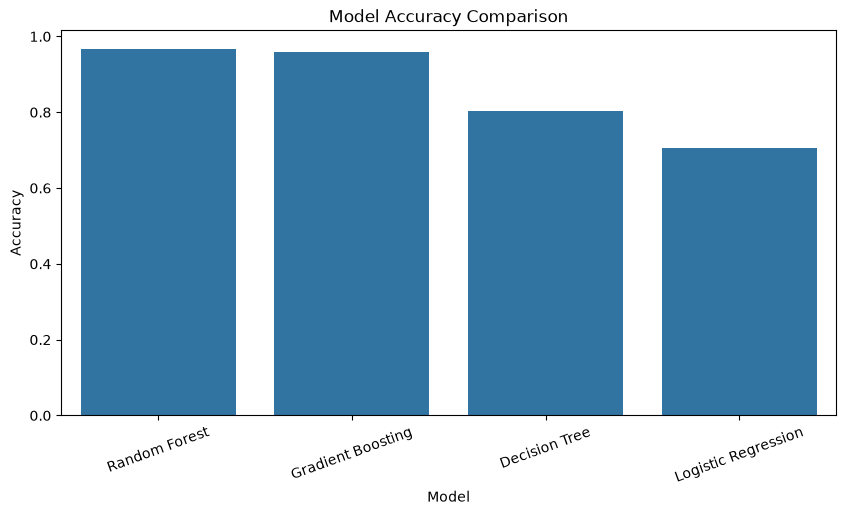

In [138]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=comparison_df,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)
plt.show()

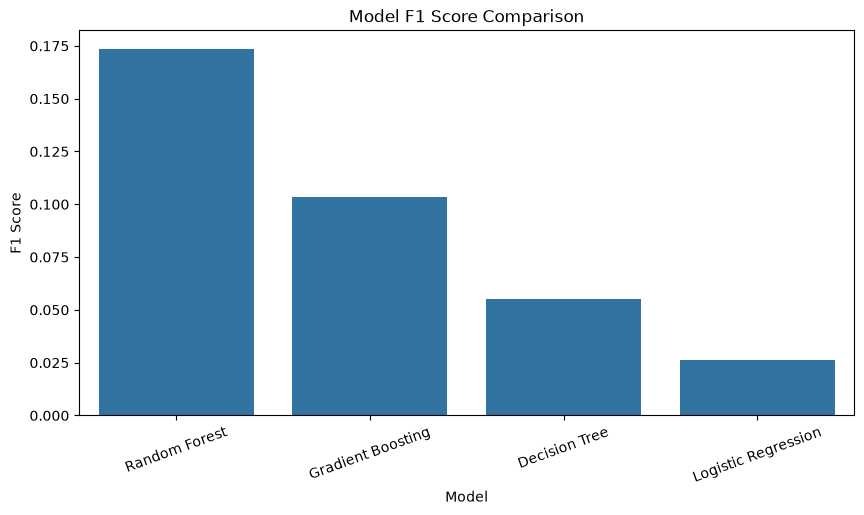

In [139]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=comparison_df,
    x="Model",
    y="F1 Score"
)

plt.title("Model F1 Score Comparison")
plt.xticks(rotation=20)
plt.show()

In [140]:
comparison_df.to_csv(
    "model_comparison.csv",
    index=False
)
print("Model Comparison Saved Successfully")

Model Comparison Saved Successfully


In [141]:
# ==========================================================
# Import ROC Curve Libraries
# ==========================================================

from sklearn.metrics import roc_curve, roc_auc_score

In [142]:
# ==========================================================
# Prediction Probabilities
# ==========================================================

lr_prob = logistic_model.predict_proba(X_test)[:, 1]

dt_prob = decision_tree.predict_proba(X_test)[:, 1]

rf_prob = random_forest.predict_proba(X_test)[:, 1]

gb_prob = gradient_boost.predict_proba(X_test)[:, 1]

print("Prediction Probabilities Generated Successfully")

Prediction Probabilities Generated Successfully


In [143]:
# ==========================================================
# Calculate AUC Scores
# ==========================================================

lr_auc = roc_auc_score(y_test, lr_prob)

dt_auc = roc_auc_score(y_test, dt_prob)

rf_auc = roc_auc_score(y_test, rf_prob)

gb_auc = roc_auc_score(y_test, gb_prob)

print("Logistic Regression AUC :", round(lr_auc,4))
print("Decision Tree AUC       :", round(dt_auc,4))
print("Random Forest AUC       :", round(rf_auc,4))
print("Gradient Boosting AUC   :", round(gb_auc,4))

Logistic Regression AUC : 0.5208
Decision Tree AUC       : 0.6116
Random Forest AUC       : 0.7265
Gradient Boosting AUC   : 0.6469


In [144]:
# ==========================================================
# ROC Curve Coordinates
# ==========================================================

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)

dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_prob)

print("ROC Coordinates Generated")

ROC Coordinates Generated


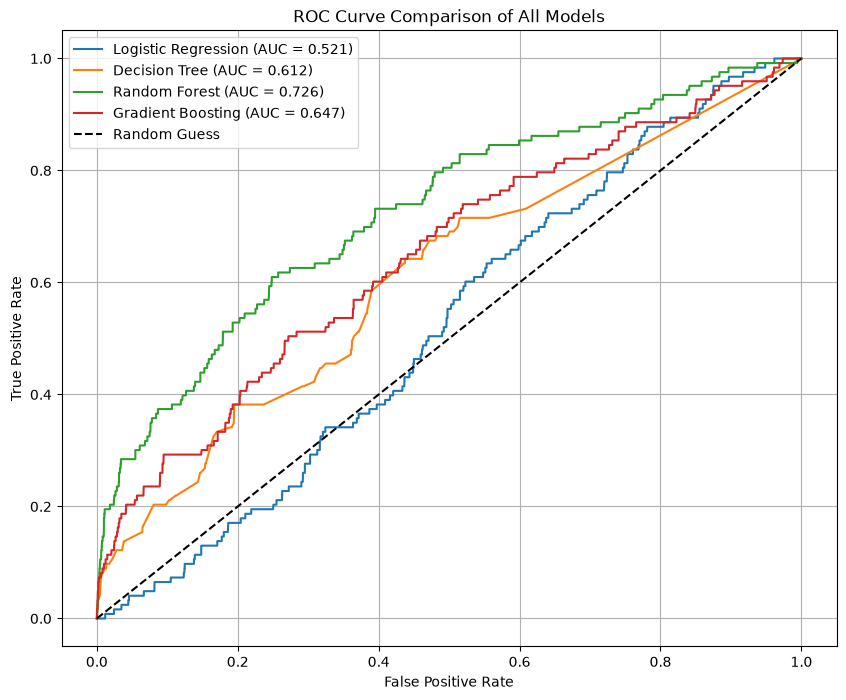

In [145]:
# ==========================================================
# ROC Curve Comparison
# ==========================================================

plt.figure(figsize=(10,8))
plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC = {lr_auc:.3f})"
)

plt.plot(
    dt_fpr,
    dt_tpr,
    label=f"Decision Tree (AUC = {dt_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    gb_fpr,
    gb_tpr,
    label=f"Gradient Boosting (AUC = {gb_auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black",
    label="Random Guess"
)

plt.title("ROC Curve Comparison of All Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

In [146]:
# ==========================================================
# AUC Comparison Table
# ==========================================================

auc_df = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],

    "AUC Score":[
        lr_auc,
        dt_auc,
        rf_auc,
        gb_auc
    ]

})

auc_df = auc_df.sort_values(
    by="AUC Score",
    ascending=False
)
auc_df

,Model,AUC Score
2,Random Forest,0.726488
3,Gradient Boosting,0.646862
1,Decision Tree,0.611571
0,Logistic Regression,0.520769


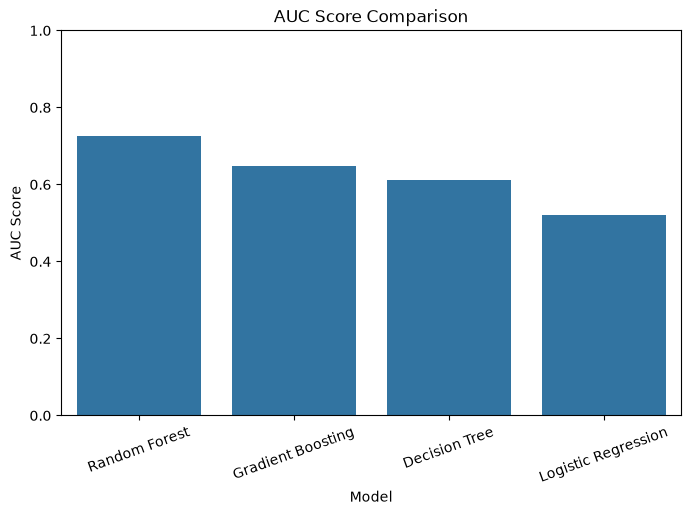

In [147]:
# ==========================================================
# AUC Score Comparison
# ==========================================================

plt.figure(figsize=(8,5))
sns.barplot(
    data=auc_df,
    x="Model",
    y="AUC Score"
)

plt.title("AUC Score Comparison")
plt.xticks(rotation=20)
plt.ylim(0,1)
plt.show()

In [148]:
# ==========================================================
# Save AUC Results
# ==========================================================

auc_df.to_csv(
    "auc_comparison.csv",
    index=False
)

print("AUC Comparison Saved Successfully")

AUC Comparison Saved Successfully


In [149]:
# ==========================================================
# Feature Importance
# ==========================================================

feature_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": random_forest.feature_importances_

})
feature_importance.head()

,Feature,Importance
0,CODE_GENDER,0.014403
1,FLAG_OWN_CAR,0.036074
2,FLAG_OWN_REALTY,0.071004
3,CNT_CHILDREN,0.022345
4,AMT_INCOME_TOTAL,0.066432


In [150]:
# ==========================================================
# Sort Features
# ==========================================================

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
feature_importance

,Feature,Importance
16,CNT_FAM_MEMBERS,0.097582
9,DAYS_BIRTH,0.094587
17,AGE,0.082940
10,DAYS_EMPLOYED,0.074106
2,FLAG_OWN_REALTY,0.071004
4,AMT_INCOME_TOTAL,0.066432
18,EMPLOYED_YEARS,0.065824
19,INCOME_PER_PERSON,0.061388
20,CHILD_RATIO,0.059624
15,OCCUPATION_TYPE,0.054986


In [151]:
# ==========================================================
# Top 10 Features
# ==========================================================

top10 = feature_importance.head(10)
top10

,Feature,Importance
16,CNT_FAM_MEMBERS,0.097582
9,DAYS_BIRTH,0.094587
17,AGE,0.082940
10,DAYS_EMPLOYED,0.074106
2,FLAG_OWN_REALTY,0.071004
4,AMT_INCOME_TOTAL,0.066432
18,EMPLOYED_YEARS,0.065824
19,INCOME_PER_PERSON,0.061388
20,CHILD_RATIO,0.059624
15,OCCUPATION_TYPE,0.054986


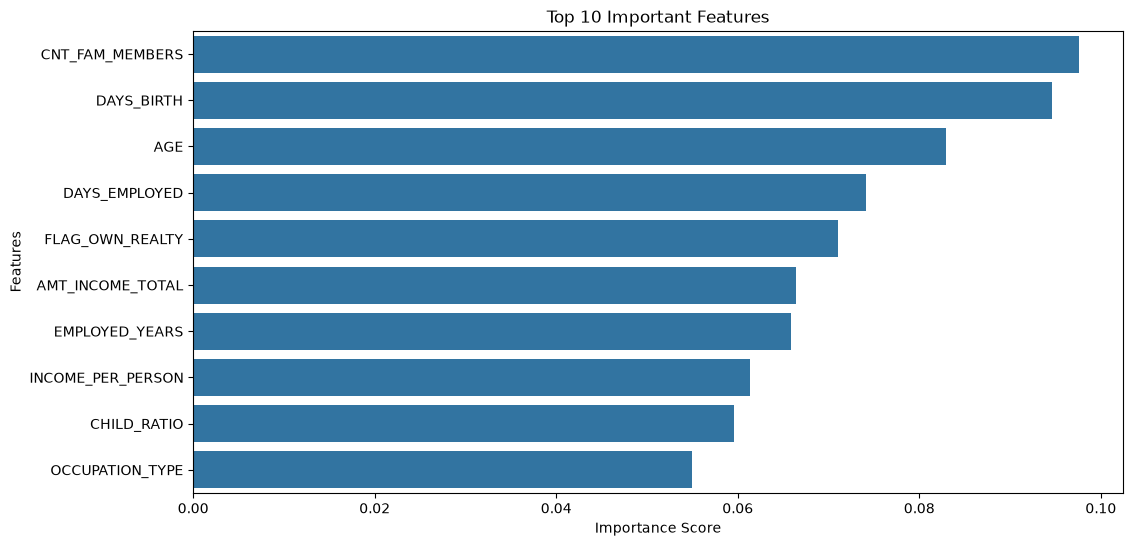

In [152]:
# ==========================================================
# Feature Importance Plot
# ==========================================================

plt.figure(figsize=(12,6))
sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

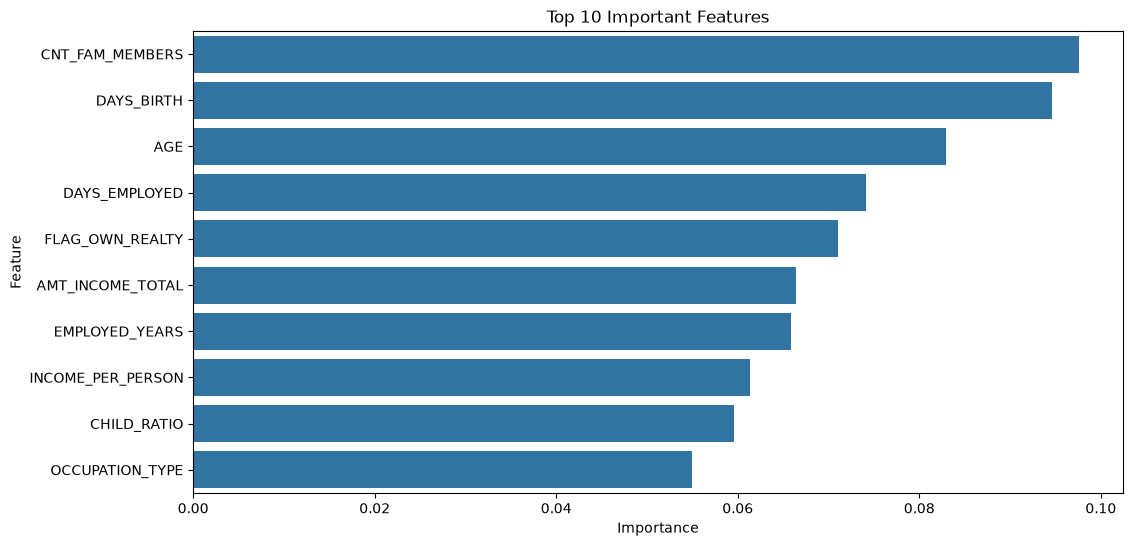

Feature Importance Saved Successfully


In [153]:
# ==========================================================
# Save Graph
# ==========================================================

plt.figure(figsize=(12,6))
sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
print("Feature Importance Saved Successfully")

In [154]:
feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)
print("CSV Saved Successfully")

CSV Saved Successfully


In [155]:
print(top10)

              Feature  Importance
16    CNT_FAM_MEMBERS    0.097582
9          DAYS_BIRTH    0.094587
17                AGE    0.082940
10      DAYS_EMPLOYED    0.074106
2     FLAG_OWN_REALTY    0.071004
4    AMT_INCOME_TOTAL    0.066432
18     EMPLOYED_YEARS    0.065824
19  INCOME_PER_PERSON    0.061388
20        CHILD_RATIO    0.059624
15    OCCUPATION_TYPE    0.054986


In [156]:
# ==========================================================
# Import Libraries
# ==========================================================

from sklearn.model_selection import RandomizedSearchCV

In [157]:
# ==========================================================
# Random Forest Parameter Grid
# ==========================================================

param_grid = {

    "n_estimators": [100, 200, 300, 400, 500],

    "max_depth": [5, 10, 15, 20, None],

    "min_samples_split": [2, 5, 10, 20],

    "min_samples_leaf": [1, 2, 4, 5, 10],

    "max_features": ["sqrt", "log2"],

    "bootstrap": [True, False]

}

In [158]:
# ==========================================================
# Base Random Forest
# ==========================================================

rf_base = RandomForestClassifier(
    random_state=42
)

In [159]:
# ==========================================================
# Randomized Search
# ==========================================================

random_search = RandomizedSearchCV(

    estimator=rf_base,

    param_distributions=param_grid,

    n_iter=20,

    scoring="f1",

    cv=5,

    verbose=2,

    random_state=42,

    n_jobs=-1

)

In [160]:
# ==========================================================
# Hyperparameter Tuning
# ==========================================================

random_search.fit(
    X_train_smote,
    y_train_smote
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True, False], 'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the 

In [161]:
# ==========================================================
# Best Parameters
# ==========================================================

print("Best Parameters")
print(random_search.best_params_)

Best Parameters
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20, 'bootstrap': False}


In [162]:
# ==========================================================
# Best Cross-Validation Score
# ==========================================================

print("Best F1 Score")
print(random_search.best_score_)

Best F1 Score
0.9890524497441179


In [163]:
# ==========================================================
# Best Model
# ==========================================================

best_rf = random_search.best_estimator_
print(best_rf)

RandomForestClassifier(bootstrap=False, max_depth=20, max_features='log2',
                       min_samples_leaf=2, n_estimators=500, random_state=42)


In [164]:
# ==========================================================
# Predictions
# ==========================================================

y_pred_best = best_rf.predict(X_test)

In [165]:
# ==========================================================
# Accuracy
# ==========================================================

best_accuracy = accuracy_score(
    y_test,
    y_pred_best
)

print(
    "Tuned Random Forest Accuracy : {:.2f}%".format(
        best_accuracy * 100
    )
)

Tuned Random Forest Accuracy : 97.60%


In [166]:
# ==========================================================
# Confusion Matrix
# ==========================================================

cm_best = confusion_matrix(
    y_test,
    y_pred_best
)
print(cm_best)

[[7089   80]
 [  95   28]]


In [167]:
# ==========================================================
# Classification Report
# ==========================================================

print(
    classification_report(
        y_test,
        y_pred_best
    )
)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7169
           1       0.26      0.23      0.24       123

    accuracy                           0.98      7292
   macro avg       0.62      0.61      0.62      7292
weighted avg       0.97      0.98      0.98      7292



In [168]:
# ==========================================================
# Comparison
# ==========================================================

print("Original Random Forest Accuracy : {:.2f}%".format(accuracy_rf * 100))
print("Tuned Random Forest Accuracy    : {:.2f}%".format(best_accuracy * 100))

Original Random Forest Accuracy : 96.74%
Tuned Random Forest Accuracy    : 97.60%


In [169]:
# ==========================================================
# Import Libraries
# ==========================================================

import os
import joblib
print("Libraries Imported Successfully")

Libraries Imported Successfully


In [170]:
# ==========================================================
# Create Models Folder
# ==========================================================

os.makedirs("models", exist_ok=True)
print("Models Folder Ready")

Models Folder Ready


In [171]:
# ==========================================================
# Save Final Machine Learning Model
# ==========================================================

joblib.dump(
    best_rf,
    "models/best_model.pkl"
)

print("Best Model Saved Successfully")

Best Model Saved Successfully


In [172]:
# ==========================================================
# Save Standard Scaler
# ==========================================================

joblib.dump(
    scaler,
    "models/scaler.pkl"
)

print("Scaler Saved Successfully")

Scaler Saved Successfully


In [173]:
import joblib

joblib.dump(
    label_encoders,
    "../models/label_encoders.pkl"
)

print("Saved Successfully")

Saved Successfully


In [174]:
# ==========================================================
# Save Feature Order
# ==========================================================

feature_columns = X_train.columns.tolist()

joblib.dump(
    feature_columns,
    "models/feature_columns.pkl"
)

print(feature_columns)

['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'AGE', 'EMPLOYED_YEARS', 'INCOME_PER_PERSON', 'CHILD_RATIO']


In [180]:
os.makedirs("models", exist_ok=True)

joblib.dump(label_encoders, "models/label_encoders.pkl")

print("Label Encoders Saved Successfully")

Label Encoders Saved Successfully


In [175]:
# ==========================================================
# Check Saved Files
# ==========================================================

print(os.listdir("models"))

['best_model.pkl', 'feature_columns.pkl', 'scaler.pkl']


In [176]:
# ==========================================================
# Load Model
# ==========================================================

loaded_model = joblib.load(
    "models/best_model.pkl"
)

print(type(loaded_model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [181]:
print(os.listdir("models"))

['best_model.pkl', 'feature_columns.pkl', 'label_encoders.pkl', 'scaler.pkl']
